<a href="https://colab.research.google.com/github/CD-GRUPO3/TA047R-1C2025-GRUPO03/blob/main/TA047R_TP1_GRUPO03_ENTREGA_EJ4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Grupo 3 - Ejercicio 4: *Agrupamiento (Clustering)*
**Objetivo:** analizar si es posible agrupar los datos de un conjunto de datos que contiene información sobre algunos tracks (canciones) de Spotify, en función de algún criterio, mediante el algoritmo K-Means.


**Integrantes:**
- ARIAS, Rafaela Pilar. 112272. rparias@fi.uba.ar.
- BARCALA ROCA, Ramiro. 112478. rbarcala@fi.uba.ar.
- LEMA, Mora. 111831. molema@fi.uba.ar.
- IENCO, Lara Eliana. 111921. lienco@fi.uba.ar.
___

####Bibliografía:


##Inicialización del entorno

In [ ]:
import pandas as pd #Manipulación y análisis de datos
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.cluster import KMeans

from sklearn.manifold import TSNE

from sklearn.decomposition import PCA

In [ ]:
!gdown 1hUQM0DIbP41STW2Mhk5_zk1fpYD0y4I_

Downloading...
From: https://drive.google.com/uc?id=1hUQM0DIbP41STW2Mhk5_zk1fpYD0y4I_
To: /content/playlist_spotify.csv
100% 54.4k/54.4k [00:00<00:00, 108MB/s]


##Análisis exploratorio

In [ ]:
data =pd.read_csv('playlist_spotify.csv')

In [ ]:
data

,acousticness,danceability,duration,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence
0,0.713000,0.514,100125,0.521,0.816000,8,0.1120,-14.835,0,0.0444,119.879,4,0.143
1,0.192000,0.714,207019,0.614,0.000000,4,0.2630,-6.935,1,0.0319,123.969,4,0.582
2,0.333000,0.630,216200,0.455,0.000004,5,0.1270,-9.290,1,0.0292,139.931,4,0.199
3,0.601000,0.810,136413,0.221,0.210000,5,0.1840,-11.005,1,0.0429,109.960,4,0.798
4,0.883000,0.465,181440,0.459,0.000173,6,0.0692,-8.137,0,0.0351,90.807,4,0.288
...,...,...,...,...,...,...,...,...,...,...,...,...,...
745,0.000175,0.374,333827,0.943,0.000156,6,0.1250,-4.108,0,0.0556,112.084,4,0.338
746,0.001970,0.487,213000,0.867,0.006020,10,0.0968,-3.293,0,0.0543,160.048,4,0.403
747,0.916000,0.605,125867,0.314,0.000000,0,0.3590,-7.631,1,0.0327,138.148,4,0.836
748,0.168000,0.700,249493,0.823,0.000028,3,0.1220,-6.892,1,0.0373,144.060,4,0.745


| Variable           | Descripción |
|--------------------|-------------|
| `acousticness`     | Medida de confianza sobre si la pista es acústica. Valores entre 0.0 y 1.0. |
| `danceability`     | Qué tan adecuada es la pista para bailar, según su ritmo, tempo, estabilidad, etc. |
| `energy`           | Nivel de intensidad y actividad percibida en la pista. Entre 0.0 y 1.0. |
| `instrumentalness` | Predice si la pista no tiene voces. Valores cercanos a 1.0 indican que es instrumental. |
| `key`              | Tono en el que está la canción, como número entero (por ejemplo, 0 = C, 1 = C#/Db, etc.). -1 si no se detecta. |
| `liveness`         | Estima si hay presencia de público. Valores altos indican que puede ser una grabación en vivo. |
| `loudness`         | Volumen promedio de la pista en decibelios (dB). Normalmente valores negativos. |
| `mode`             | Modalidad de la escala: 1 es mayor, 0 es menor. |
| `speechiness`      | Mide la presencia de palabras habladas. Más cerca de 1.0 = más hablada. |
| `tempo`            | Tempo estimado de la pista en BPM (pulsos por minuto). |
| `time_signature`   | Número estimado de tiempos por compás. |
| `valence`          | Qué tan positiva o alegre suena la pista. Valores altos = más feliz. |
| `duration_ms`      | Duración total de la pista en milisegundos. |
| `id`               | Identificador único de Spotify para la pista. |
| `uri`              | URI de Spotify para acceder a la pista. |
| `track_href`       | Enlace al endpoint de la API con más información de la pista. |
| `analysis_url`     | URL para acceder al análisis de audio completo de la pista. |
| `type`             | Siempre será `audio_features` para este endpoint. |


In [ ]:
shape = data.shape
print("Filas: %d\nColumnas: %d" % (shape[0], shape[1]))

Filas: 750
Columnas: 13


In [ ]:
print("Cantidad total de NaN en el dataset:", data.isnull().sum().sum())
if(data.isnull().sum().sum()) == 0:
  print("No hay datos faltantes!")

Cantidad total de NaN en el dataset: 0
No hay datos faltantes!


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 750 entries, 0 to 749
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   acousticness      750 non-null    float64
 1   danceability      750 non-null    float64
 2   duration          750 non-null    int64  
 3   energy            750 non-null    float64
 4   instrumentalness  750 non-null    float64
 5   key               750 non-null    int64  
 6   liveness          750 non-null    float64
 7   loudness          750 non-null    float64
 8   mode              750 non-null    int64  
 9   speechiness       750 non-null    float64
 10  tempo             750 non-null    float64
 11  time_signature    750 non-null    int64  
 12  valence           750 non-null    float64
dtypes: float64(9), int64(4)
memory usage: 76.3 KB


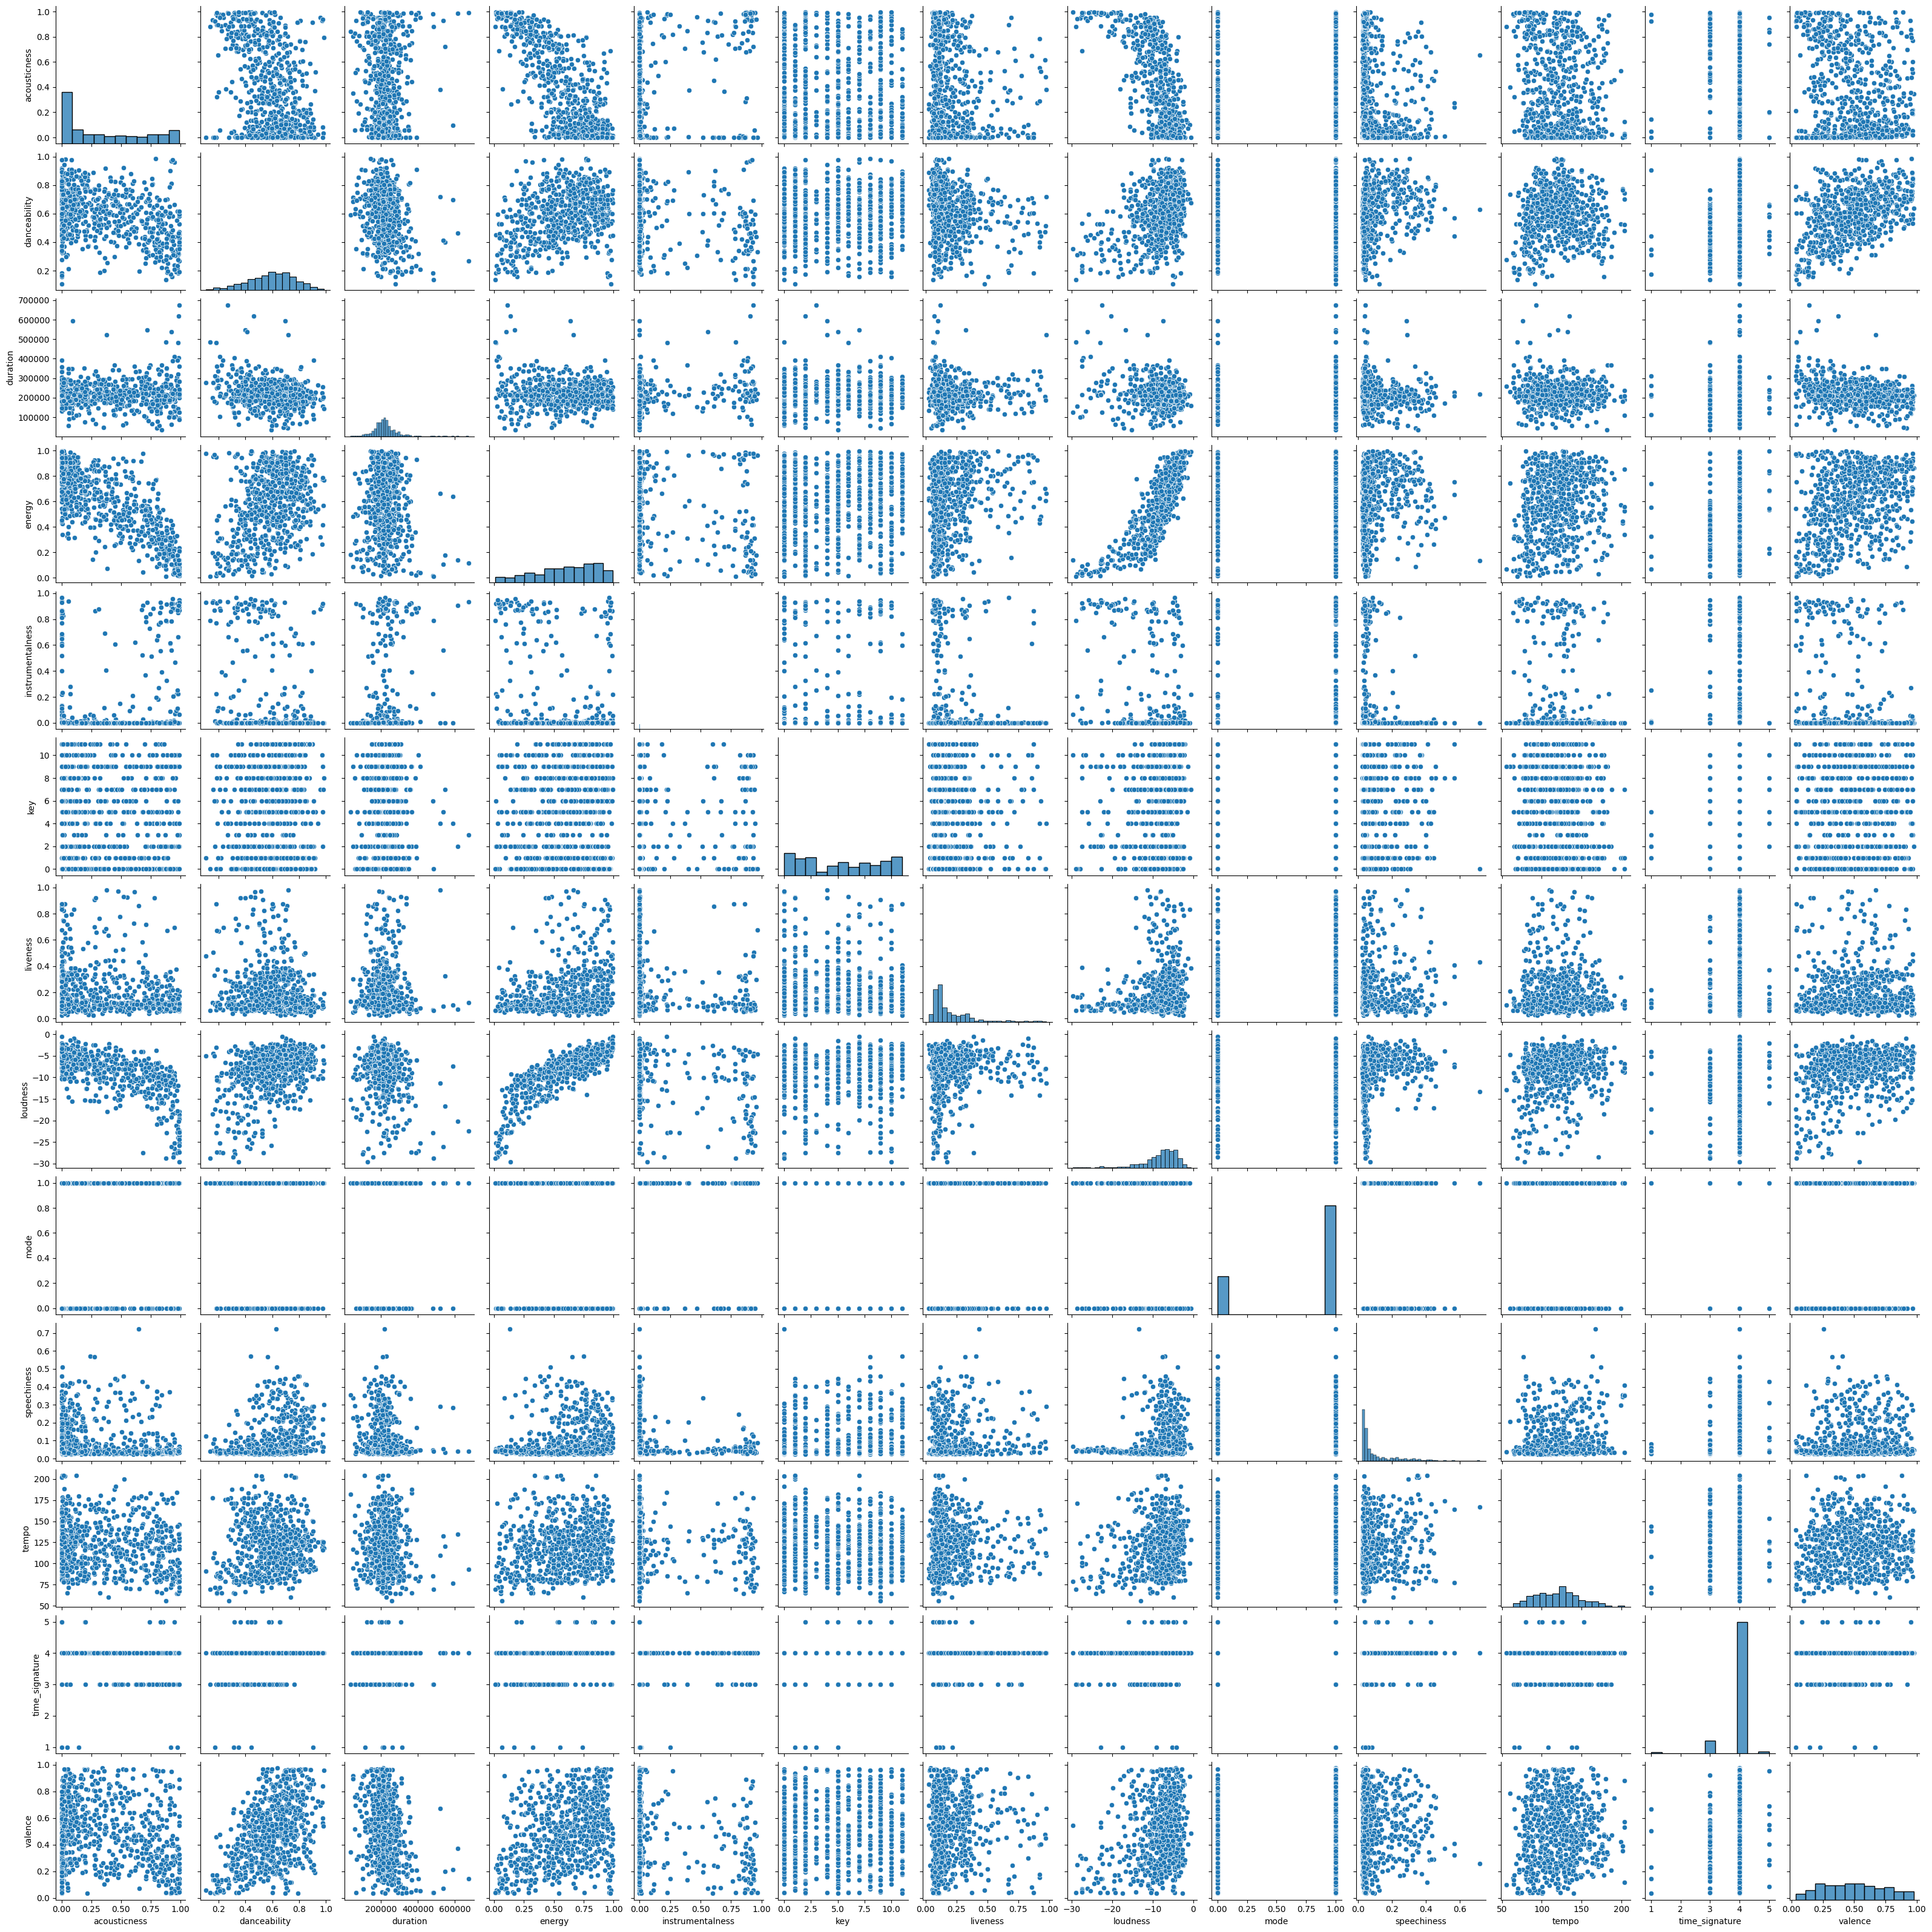

In [ ]:
sns.pairplot(data)
plt.show()

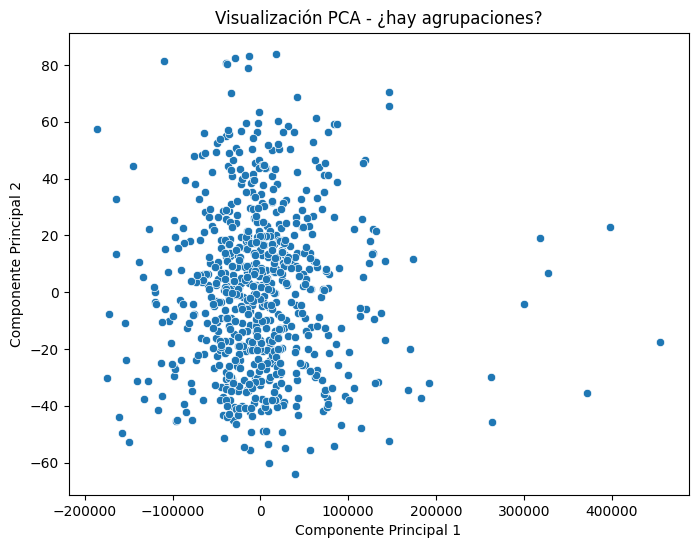

In [ ]:
pca = PCA(n_components=2)
data_pca = pca.fit_transform(data)

# Visualización
plt.figure(figsize=(8,6))
sns.scatterplot(x=data_pca[:,0], y=data_pca[:,1])
plt.title("Visualización PCA - ¿hay agrupaciones?")
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.show()

LARA: AGREGUÉ:

A simple vista, se pueden distinguir posibles agrupamientos, aunque algunos se superponen. Esto sugiere que K-Means podría encontrar cierta estructura.

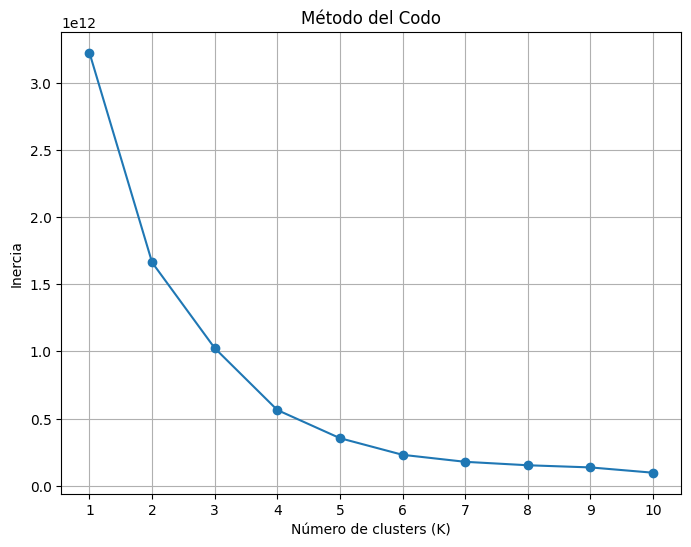

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertias = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(data)
    inertias.append(kmeans.inertia_)

# Gráfico del codo
plt.figure(figsize=(8,6))
plt.plot(k_range, inertias, marker='o')
plt.title('Método del Codo')
plt.xlabel('Número de clusters (K)')
plt.ylabel('Inercia')
plt.xticks(k_range)
plt.grid(True)
plt.show()

Estimamos que 5 o 6 clusteres es una buena cantidad de grupos.

Lara -> esto agregue yo, igualmente deje lo viejo arriba q no se bien como iban a querer seguirlo

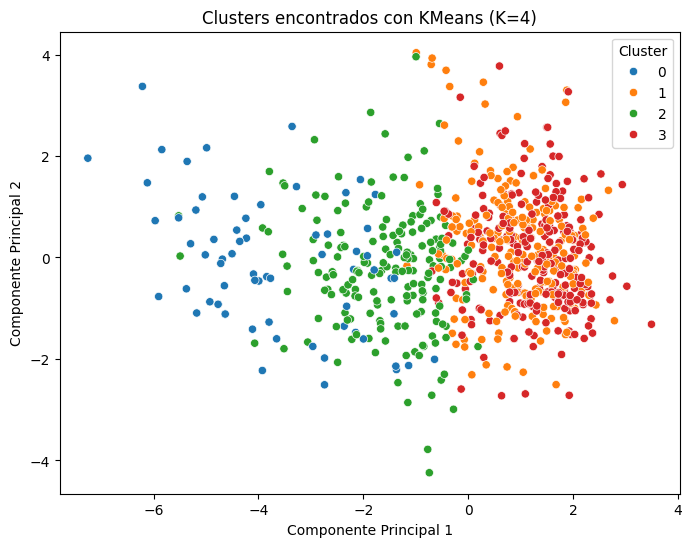

In [ ]:
# Estandarizamos los datos antes de aplicar KMeans
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)

# Aplicamos KMeans con K=4
kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(data_scaled)

# Agregamos los clusters como nueva columna para análisis posterior
data['cluster'] = clusters

# Visualización con PCA (2D)
pca = PCA(n_components=2)
data_pca = pca.fit_transform(data_scaled)

plt.figure(figsize=(8,6))
sns.scatterplot(x=data_pca[:,0], y=data_pca[:,1], hue=clusters, palette="tab10")
plt.title("Clusters encontrados con KMeans (K=4)")
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.legend(title="Cluster")
plt.show()

Silhouette Score

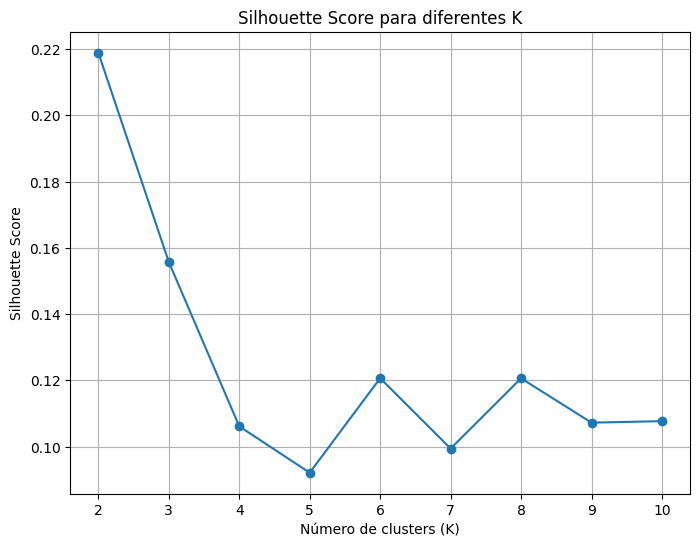

In [ ]:
silhouette_scores = []
k_values = range(2, 11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(data_scaled)
    score = silhouette_score(data_scaled, labels)
    silhouette_scores.append(score)

# Graficamos los resultados
plt.figure(figsize=(8,6))
plt.plot(k_values, silhouette_scores, marker='o')
plt.title('Silhouette Score para diferentes K')
plt.xlabel('Número de clusters (K)')
plt.ylabel('Silhouette Score')
plt.xticks(k_values)
plt.grid(True)
plt.show()

Observamos que el valor más alto del Silhouette Score se alcanza con K = 2, lo cual sugiere que dividir los datos en 2 grupos resulta en la mejor separación y cohesión entre clusters. Aunque K = 6 y K = 8 también muestran valores relativamente buenos, ninguno supera la calidad del agrupamiento con K = 2.